In [44]:
%pip install pypdf langgraph python-dotenv langchain-ollama langchain-groq python-jobspy langchain_tavily pillow graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import os
import sys
from langchain_core.runnables.graph import MermaidDrawMethod

# 1. Force the notebook to look at your project root
# This ensures it finds 'services', 'Core', 'Job_match', etc.
project_root = r"C:\Users\IAN\Documents\Main projects\elevate node testing"
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Use .insert(0) to put it at the very front

# 2. Now run the imports
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# 1. IMPORT YOUR UNIFIED STATE
from Core.Unifiedstate import IndigoMasterState 
# ... rest of your imports

In [46]:

from services.parser.pdf_reader_n_clearner import pdf_reader
from Job_match.agents.Resume_extraction_agent import Resume_extaction
from Job_match.agents.suggested_Job_formating import suggested_Job_formating
from services.scraper.Job_scraper import fetch_jobs
from Core.Nodes.select_job import select_job_details
from Job_match.agents.resume_rewrite_agent import resume_rewrite
from Job_match.agents.human_rewritter_agent import human_rewritter_agent
from Agents.Pivot.discovery import discovery_search_node
from Agents.Pivot.brainstormer import path_brainstormer_node
from Agents.Pivot.validator import market_validation_node
from Agents.Pivot.roadmap import roadmap_generator_node
from Agents.Pivot.loopback import resume_loopback_node
from Core.Nodes.human_gate import human_decision_gate
from Agents.Goals.goals import goal_analysis_node
from Agents.Goals.estimator import universal_reality_check_node
from Core.Nodes.Conditions import route_user_intent
from Agents.Find_my_cycle.circle_test import generate_circle_parameters_node, real_social_search_node

from Core.Nodes.Conditions import (
    critic_resume_rewrite_condition,
    skill_extraction_condition,
    ingestion_condition
)


✅ Success! Graph saved as 'graph_output.png' in your project folder.


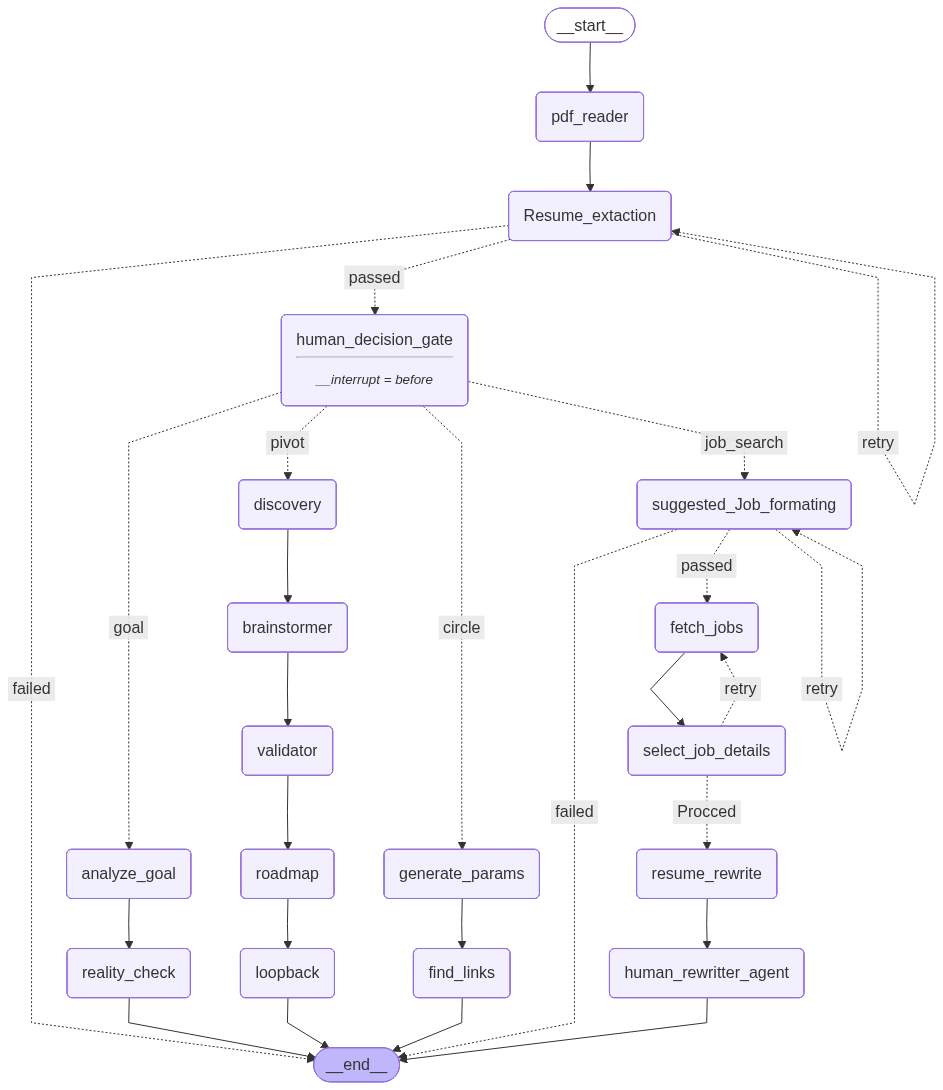

In [47]:
from IPython.display import Image, display

def build_unified_graph():
    builder = StateGraph(IndigoMasterState)

    # 1. ADD NODES
    builder.add_node('pdf_reader', pdf_reader)
    builder.add_node('Resume_extaction', Resume_extaction)
    builder.add_node("human_decision_gate", human_decision_gate)

    # Spoke A: Job Match
    builder.add_node('suggested_Job_formating', suggested_Job_formating)
    builder.add_node('fetch_jobs', fetch_jobs)
    builder.add_node('select_job_details', select_job_details) 
    builder.add_node('resume_rewrite', resume_rewrite)
    builder.add_node('human_rewritter_agent', human_rewritter_agent)

    # Spoke B: Pivot
    builder.add_node("discovery", discovery_search_node)
    builder.add_node("brainstormer", path_brainstormer_node)
    builder.add_node("validator", market_validation_node)
    builder.add_node("roadmap", roadmap_generator_node)
    builder.add_node("loopback", resume_loopback_node)

    # Spoke C: Goals
    builder.add_node("analyze_goal", goal_analysis_node)
    builder.add_node("reality_check", universal_reality_check_node)
    
    # Spoke D: Find My Circle (Networking)
    builder.add_node("generate_params", generate_circle_parameters_node)
    builder.add_node("find_links", real_social_search_node)

    # 2. DEFINE EDGES
    builder.add_edge(START, 'pdf_reader')
    builder.add_edge('pdf_reader', 'Resume_extaction')

    builder.add_conditional_edges(
        "Resume_extaction", 
        ingestion_condition, 
        {
            "passed": "human_decision_gate", 
            "retry": "Resume_extaction",
            "failed": END
        }
    )

    builder.add_conditional_edges(
        "human_decision_gate", 
        route_user_intent, 
        {
            "job_search": "suggested_Job_formating",
            "pivot": "discovery",
            "goal": "analyze_goal",
            "circle": "generate_params"
        }
    )

    # --- SPOKE A FLOW ---
    builder.add_conditional_edges('suggested_Job_formating', skill_extraction_condition, {
        "passed": 'fetch_jobs', 
        "retry": 'suggested_Job_formating',
        "failed": END
    })
    builder.add_edge('fetch_jobs', 'select_job_details')
    builder.add_conditional_edges('select_job_details', critic_resume_rewrite_condition, {
        "Procced": 'resume_rewrite',
        "retry": 'fetch_jobs' 
    })
    builder.add_edge('resume_rewrite', 'human_rewritter_agent')
    builder.add_edge('human_rewritter_agent', END)

    # --- SPOKE B FLOW ---
    builder.add_edge("discovery", "brainstormer")
    builder.add_edge("brainstormer", "validator")
    builder.add_edge("validator", "roadmap")
    builder.add_edge("roadmap", "loopback")
    builder.add_edge("loopback", END)

    # --- SPOKE C FLOW ---
    builder.add_edge("analyze_goal", "reality_check")
    builder.add_edge("reality_check", END)

    # --- SPOKE D FLOW ---
    builder.add_edge("generate_params", "find_links")
    builder.add_edge("find_links", END)

    # 3. COMPILE AND RETURN
    memory = MemorySaver()
    # CRITICAL: We return the compiled graph so we can use it outside the function
    return builder.compile(
        checkpointer=memory,
        interrupt_before=["human_decision_gate"]
    )

# --- EXECUTION BLOCK ---

# 1. Generate the graph object
app = build_unified_graph()

# 2. Save it to a file (The "Old Way" that always works)
try:
    with open("graph_output.png", "wb") as f:
        f.write(app.get_graph().draw_mermaid_png())
    print("✅ Success! Graph saved as 'graph_output.png' in your project folder.")
except Exception as e:
    print(f"Drawing failed: {e}")

# 3. Try to display it in the notebook as a backup
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    pass